# NB01 — Data Loading, Cleaning & Exploratory Data Analysis
---

**Purpose:** Load all three raw datasets, inspect their structure, clean them, and perform initial exploratory analysis so we understand what we're working with before diving into specific analytics.

**Why this matters in product analytics:**
Before you can answer any business question, you need to trust your data. In industry, product analysts spend a significant portion of their time on data quality — checking for missing values, duplicates, inconsistent formats, and unexpected distributions. Skipping this step leads to wrong conclusions.

**Outputs:** Cleaned CSVs saved to `data/inputs/` for all downstream notebooks.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set consistent style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 100

# Paths
RAW = '../data/raw/'
INPUTS = '../data/inputs/'
OUTPUTS = '../data/outputs/nb01/'

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 1. Load Raw Datasets

We have three datasets:
1. **User Funnels** — tracks users through product stages (landing → signup → product view → add to cart → purchase)
2. **A/B Testing** — experiment data comparing a control vs. treatment group
3. **User Activity** — longitudinal user behavior data for cohort and retention analysis

In [2]:
# Load all three datasets
funnel_df = pd.read_csv(f'{RAW}user_funnels_dataset.csv', parse_dates=['signup_date', 'timestamp'])
ab_df = pd.read_csv(f'{RAW}ab_testing_dataset.csv', parse_dates=['session_date'])
activity_df = pd.read_csv(f'{RAW}user_activity_dataset.csv', parse_dates=['signup_date', 'activity_date'])

print('=== Dataset Shapes ===')
print(f'Funnel:   {funnel_df.shape[0]:,} rows x {funnel_df.shape[1]} cols | {funnel_df["user_id"].nunique():,} unique users')
print(f'A/B Test: {ab_df.shape[0]:,} rows x {ab_df.shape[1]} cols | {ab_df["user_id"].nunique():,} unique users')
print(f'Activity: {activity_df.shape[0]:,} rows x {activity_df.shape[1]} cols | {activity_df["user_id"].nunique():,} unique users')

=== Dataset Shapes ===
Funnel:   14,433 rows x 7 cols | 5,000 unique users
A/B Test: 4,000 rows x 8 cols | 4,000 unique users
Activity: 13,627 rows x 7 cols | 3,000 unique users


## 2. Data Quality Checks

**What we check and why:**
- **Missing values** — can bias analysis if not handled (e.g., missing conversions could be zeros or actual unknowns)
- **Duplicates** — double-counted events inflate metrics
- **Data types** — dates stored as strings break time-based analysis
- **Value ranges** — negative revenue or future dates indicate data pipeline errors

In [3]:
# --- Funnel Dataset Quality ---
print('=' * 60)
print('FUNNEL DATASET QUALITY REPORT')
print('=' * 60)
print(f'\nMissing values:\n{funnel_df.isnull().sum()}')
print(f'\nDuplicate rows: {funnel_df.duplicated().sum()}')
print(f'\nData types:\n{funnel_df.dtypes}')
print(f'\nStage values: {funnel_df["stage"].unique()}')
print(f'Device values: {funnel_df["device"].unique()}')
print(f'Channel values: {funnel_df["channel"].unique()}')
print(f'\nDate range: {funnel_df["signup_date"].min()} to {funnel_df["signup_date"].max()}')

FUNNEL DATASET QUALITY REPORT

Missing values:
user_id        0
signup_date    0
device         0
channel        0
stage          0
timestamp      0
reached        0
dtype: int64

Duplicate rows: 0

Data types:
user_id                object
signup_date    datetime64[ns]
device                 object
channel                object
stage                  object
timestamp      datetime64[ns]
reached                  bool
dtype: object

Stage values: ['landing_page' 'signup' 'product_view' 'add_to_cart' 'purchase']
Device values: ['mobile' 'desktop' 'tablet']
Channel values: ['organic' 'paid_search' 'email' 'social' 'referral']

Date range: 2025-01-01 00:00:00 to 2025-06-29 00:00:00


In [4]:
# --- A/B Testing Dataset Quality ---
print('=' * 60)
print('A/B TESTING DATASET QUALITY REPORT')
print('=' * 60)
print(f'\nMissing values:\n{ab_df.isnull().sum()}')
print(f'\nDuplicate rows: {ab_df.duplicated().sum()}')
print(f'\nGroup balance:\n{ab_df["group"].value_counts()}')
print(f'\nConversion rate by group:\n{ab_df.groupby("group")["converted"].mean()}')
print(f'\nRevenue stats (converted users only):')
print(ab_df[ab_df['converted']==1]['revenue'].describe())

A/B TESTING DATASET QUALITY REPORT

Missing values:
user_id                 0
group                   0
converted               0
pages_viewed            0
time_on_site_seconds    0
revenue                 0
device                  0
session_date            0
dtype: int64

Duplicate rows: 0

Group balance:
group
treatment    2003
control      1997
Name: count, dtype: int64

Conversion rate by group:
group
control      0.125188
treatment    0.180230
Name: converted, dtype: float64

Revenue stats (converted users only):
count    611.000000
mean      54.900180
std       44.063035
min        5.780000
25%       25.795000
50%       42.980000
75%       68.520000
max      298.650000
Name: revenue, dtype: float64


In [5]:
# --- Activity Dataset Quality ---
print('=' * 60)
print('USER ACTIVITY DATASET QUALITY REPORT')
print('=' * 60)
print(f'\nMissing values:\n{activity_df.isnull().sum()}')
print(f'\nDuplicate rows: {activity_df.duplicated().sum()}')
print(f'\nCohorts: {sorted(activity_df["signup_cohort"].unique())}')
print(f'Event types: {activity_df["event_type"].unique()}')
print(f'Plan types: {activity_df["plan_type"].unique()}')
print(f'\nDate range: {activity_df["activity_date"].min()} to {activity_df["activity_date"].max()}')

USER ACTIVITY DATASET QUALITY REPORT

Missing values:
user_id                 0
signup_date             0
signup_cohort           0
activity_date           0
event_type              0
session_duration_sec    0
plan_type               0
dtype: int64

Duplicate rows: 0

Cohorts: ['W01', 'W02', 'W03', 'W04', 'W05', 'W06', 'W07', 'W08', 'W09', 'W10', 'W11', 'W12']
Event types: ['page_view' 'feature_use' 'search' 'settings_change']
Plan types: ['free' 'basic' 'pro']

Date range: 2025-01-01 00:00:00 to 2025-06-10 00:00:00


## 3. Exploratory Visualizations

**Why EDA matters for product analysts:**
Before building metrics or running experiments, you need to *see* the shape of your data. Distributions tell you whether averages are meaningful (or if medians are better), whether segments behave differently, and where the interesting patterns might be hiding.

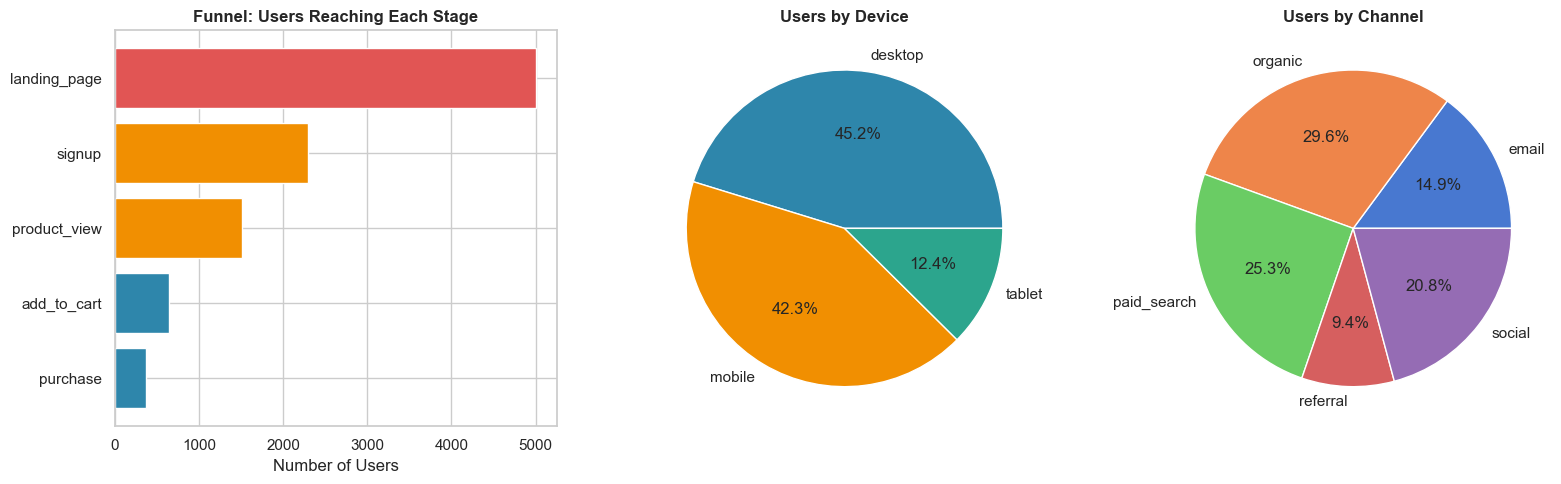

Saved: nb01_funnel_overview.png


In [6]:
# Funnel: Stage distribution
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Stage counts
stage_order = ['landing_page', 'signup', 'product_view', 'add_to_cart', 'purchase']
stage_counts = funnel_df[funnel_df['reached']==True]['stage'].value_counts().reindex(stage_order)
axes[0].barh(stage_order[::-1], stage_counts.values[::-1], color=['#2E86AB','#2E86AB','#F18F01','#F18F01','#E15554'])
axes[0].set_title('Funnel: Users Reaching Each Stage', fontweight='bold')
axes[0].set_xlabel('Number of Users')

# Device distribution
funnel_df.groupby('device')['user_id'].nunique().plot(kind='pie', ax=axes[1], autopct='%1.1f%%', colors=['#2E86AB','#F18F01','#2CA58D'])
axes[1].set_title('Users by Device', fontweight='bold')
axes[1].set_ylabel('')

# Channel distribution
funnel_df.groupby('channel')['user_id'].nunique().plot(kind='pie', ax=axes[2], autopct='%1.1f%%')
axes[2].set_title('Users by Channel', fontweight='bold')
axes[2].set_ylabel('')

plt.tight_layout()
plt.savefig(f'{OUTPUTS}nb01_funnel_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: nb01_funnel_overview.png')

In [7]:
import plotly.graph_objects as go
from pathlib import Path
import plotly.express as px
from plotly.subplots import make_subplots

# Recreate funnel overview as interactive Plotly figures
stage_order = ['landing_page', 'signup', 'product_view', 'add_to_cart', 'purchase']
stage_counts = funnel_df[funnel_df['reached']==True]['stage'].value_counts().reindex(stage_order)

# Create subplot figure with 3 subplots
fig = make_subplots(
    rows=1, cols=3,
    specs=[[{"type": "bar"}, {"type": "pie"}, {"type": "pie"}]],
    subplot_titles=('Funnel: Users Reaching Each Stage', 'Users by Device', 'Users by Channel')
)

# Stage bar chart (horizontal)
colors_stage = ['#2E86AB','#2E86AB','#F18F01','#F18F01','#E15554']
fig.add_trace(
    go.Bar(
        y=stage_order[::-1],
        x=stage_counts.values[::-1],
        orientation='h',
        marker=dict(color=colors_stage[::-1]),
        name='Stage',
        hovertemplate='<b>%{y}</b><br>Users: %{x:,}<extra></extra>'
    ),
    row=1, col=1
)

# Device pie chart
device_counts = funnel_df.groupby('device')['user_id'].nunique()
colors_device = ['#2E86AB','#F18F01','#2CA58D']
fig.add_trace(
    go.Pie(
        labels=device_counts.index,
        values=device_counts.values,
        marker=dict(colors=colors_device),
        name='Device',
        hovertemplate='<b>%{label}</b><br>Users: %{value:,}<br>%{percent}<extra></extra>'
    ),
    row=1, col=2
)

# Channel pie chart
channel_counts = funnel_df.groupby('channel')['user_id'].nunique()
fig.add_trace(
    go.Pie(
        labels=channel_counts.index,
        values=channel_counts.values,
        name='Channel',
        hovertemplate='<b>%{label}</b><br>Users: %{value:,}<br>%{percent}<extra></extra>'
    ),
    row=1, col=3
)

fig.update_xaxes(title_text='Number of Users', row=1, col=1)
fig.update_layout(height=500, showlegend=False, title_text='Funnel Overview (Interactive)')

DATA_OUTPUT = Path(OUTPUTS)
fig.write_html(str(DATA_OUTPUT / 'nb01_funnel_overview_interactive.html'), include_plotlyjs='cdn')
print('Saved: nb01_funnel_overview_interactive.html')

Saved: nb01_funnel_overview_interactive.html


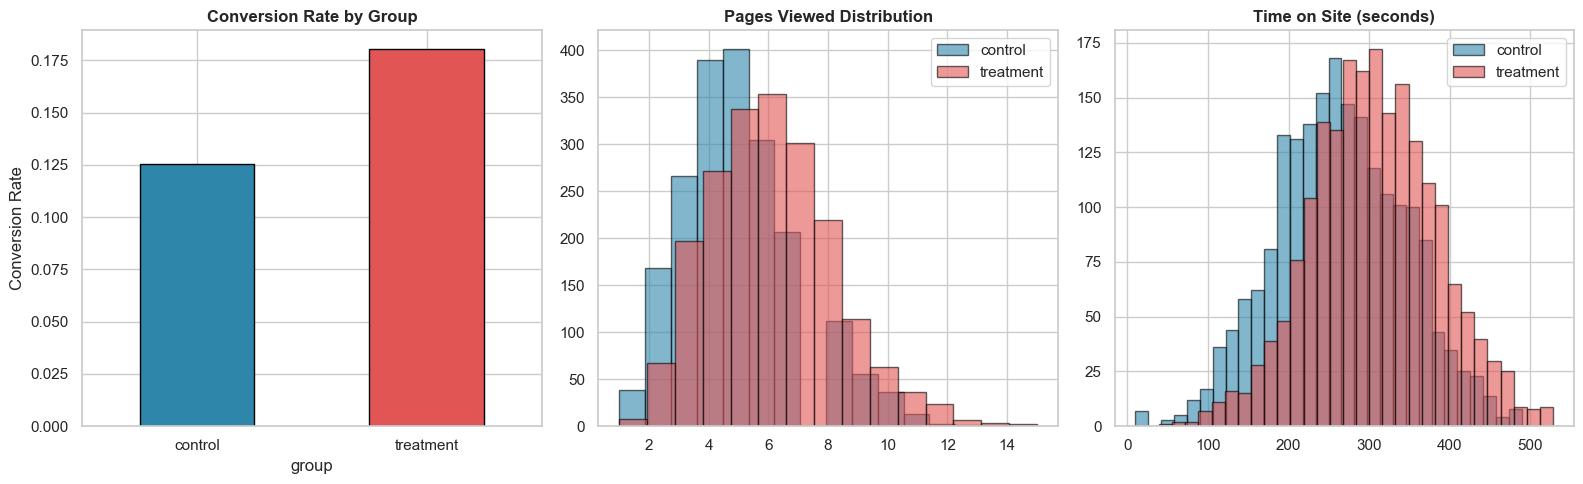

Saved: nb01_ab_overview.png


In [8]:
# A/B Test: Distribution of key metrics
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Conversion rates
conv_rates = ab_df.groupby('group')['converted'].mean()
conv_rates.plot(kind='bar', ax=axes[0], color=['#2E86AB', '#E15554'], edgecolor='black')
axes[0].set_title('Conversion Rate by Group', fontweight='bold')
axes[0].set_ylabel('Conversion Rate')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

# Pages viewed distribution
for grp, color in [('control', '#2E86AB'), ('treatment', '#E15554')]:
    subset = ab_df[ab_df['group']==grp]
    axes[1].hist(subset['pages_viewed'], bins=15, alpha=0.6, label=grp, color=color, edgecolor='black')
axes[1].set_title('Pages Viewed Distribution', fontweight='bold')
axes[1].legend()

# Time on site
for grp, color in [('control', '#2E86AB'), ('treatment', '#E15554')]:
    subset = ab_df[ab_df['group']==grp]
    axes[2].hist(subset['time_on_site_seconds'], bins=30, alpha=0.6, label=grp, color=color, edgecolor='black')
axes[2].set_title('Time on Site (seconds)', fontweight='bold')
axes[2].legend()

plt.tight_layout()
plt.savefig(f'{OUTPUTS}nb01_ab_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: nb01_ab_overview.png')

In [9]:
import plotly.graph_objects as go
from pathlib import Path
import plotly.express as px
from plotly.subplots import make_subplots

# Recreate A/B test overview as interactive Plotly figures
fig = make_subplots(
    rows=1, cols=3,
    subplot_titles=('Conversion Rate by Group', 'Pages Viewed Distribution', 'Time on Site (seconds)')
)

# Conversion rate bars
conv_rates = ab_df.groupby('group')['converted'].mean()
fig.add_trace(
    go.Bar(
        x=conv_rates.index,
        y=conv_rates.values,
        marker=dict(color=['#2E86AB', '#E15554']),
        name='Conversion Rate',
        hovertemplate='<b>%{x}</b><br>Rate: %{y:.2%}<extra></extra>'
    ),
    row=1, col=1
)

# Pages viewed histogram
for grp, color in [('control', '#2E86AB'), ('treatment', '#E15554')]:
    subset = ab_df[ab_df['group']==grp]
    fig.add_trace(
        go.Histogram(
            x=subset['pages_viewed'],
            name=grp,
            marker=dict(color=color),
            opacity=0.7,
            nbinsx=15,
            hovertemplate='Pages: %{x}<br>Count: %{y}<extra></extra>'
        ),
        row=1, col=2
    )

# Time on site histogram
for grp, color in [('control', '#2E86AB'), ('treatment', '#E15554')]:
    subset = ab_df[ab_df['group']==grp]
    fig.add_trace(
        go.Histogram(
            x=subset['time_on_site_seconds'],
            name=grp,
            marker=dict(color=color),
            opacity=0.7,
            nbinsx=30,
            showlegend=False,
            hovertemplate='Time (sec): %{x}<br>Count: %{y}<extra></extra>'
        ),
        row=1, col=3
    )

fig.update_xaxes(title_text='Group', row=1, col=1)
fig.update_yaxes(title_text='Conversion Rate', row=1, col=1)
fig.update_xaxes(title_text='Pages Viewed', row=1, col=2)
fig.update_yaxes(title_text='Frequency', row=1, col=2)
fig.update_xaxes(title_text='Time (seconds)', row=1, col=3)
fig.update_yaxes(title_text='Frequency', row=1, col=3)

fig.update_layout(height=500, barmode='overlay', title_text='A/B Test Overview (Interactive)')

DATA_OUTPUT = Path(OUTPUTS)
fig.write_html(str(DATA_OUTPUT / 'nb01_ab_overview_interactive.html'), include_plotlyjs='cdn')
print('Saved: nb01_ab_overview_interactive.html')

Saved: nb01_ab_overview_interactive.html


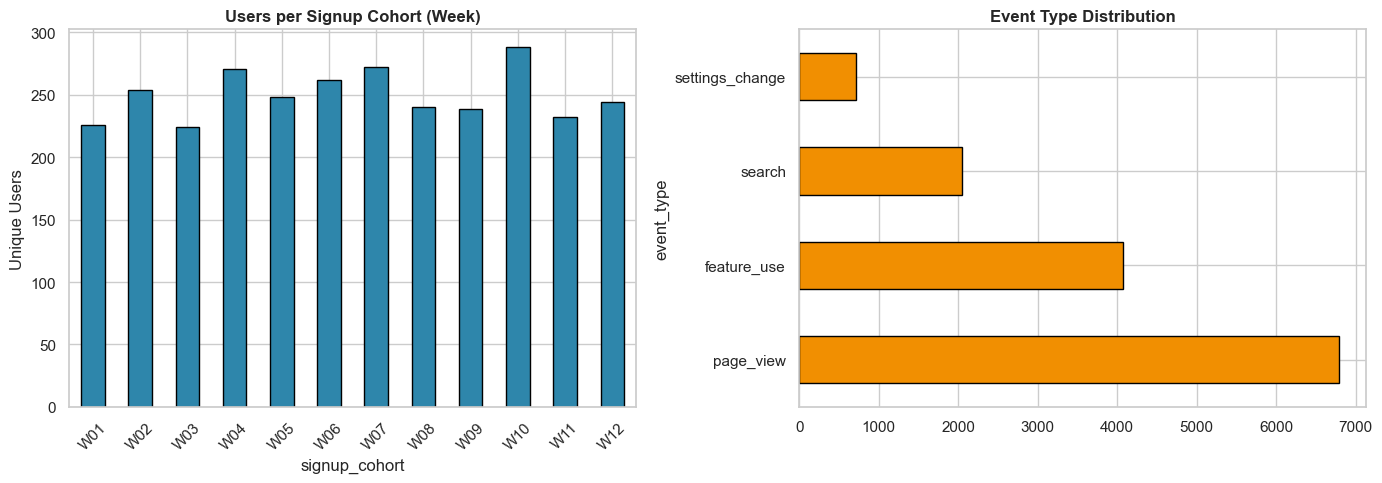

Saved: nb01_activity_overview.png


In [10]:
# Activity: Cohort sizes and event distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cohort sizes
cohort_sizes = activity_df.groupby('signup_cohort')['user_id'].nunique().sort_index()
cohort_sizes.plot(kind='bar', ax=axes[0], color='#2E86AB', edgecolor='black')
axes[0].set_title('Users per Signup Cohort (Week)', fontweight='bold')
axes[0].set_ylabel('Unique Users')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45)

# Event type distribution
activity_df['event_type'].value_counts().plot(kind='barh', ax=axes[1], color='#F18F01', edgecolor='black')
axes[1].set_title('Event Type Distribution', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{OUTPUTS}nb01_activity_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: nb01_activity_overview.png')

In [11]:
import plotly.graph_objects as go
from pathlib import Path
import plotly.express as px
from plotly.subplots import make_subplots

# Recreate activity overview as interactive Plotly figures
fig = make_subplots(
    rows=1, cols=2,
    specs=[[{"type": "bar"}, {"type": "bar"}]],
    subplot_titles=('Users per Signup Cohort (Week)', 'Event Type Distribution')
)

# Cohort sizes
cohort_sizes = activity_df.groupby('signup_cohort')['user_id'].nunique().sort_index()
fig.add_trace(
    go.Bar(
        x=cohort_sizes.index,
        y=cohort_sizes.values,
        marker=dict(color='#2E86AB'),
        name='Users',
        hovertemplate='<b>Cohort %{x}</b><br>Users: %{y:,}<extra></extra>'
    ),
    row=1, col=1
)

# Event type distribution (horizontal bar)
event_counts = activity_df['event_type'].value_counts()
fig.add_trace(
    go.Bar(
        y=event_counts.index,
        x=event_counts.values,
        orientation='h',
        marker=dict(color='#F18F01'),
        name='Events',
        hovertemplate='<b>%{y}</b><br>Count: %{x:,}<extra></extra>'
    ),
    row=1, col=2
)

fig.update_xaxes(title_text='Signup Cohort', row=1, col=1)
fig.update_yaxes(title_text='Unique Users', row=1, col=1)
fig.update_xaxes(title_text='Event Count', row=1, col=2)

fig.update_layout(height=500, showlegend=False, title_text='Activity Overview (Interactive)')

DATA_OUTPUT = Path(OUTPUTS)
fig.write_html(str(DATA_OUTPUT / 'nb01_activity_overview_interactive.html'), include_plotlyjs='cdn')
print('Saved: nb01_activity_overview_interactive.html')

Saved: nb01_activity_overview_interactive.html


## 4. Save Cleaned Data

We save clean versions to `data/inputs/` so every downstream notebook starts from the same trusted source. This is a best practice called **"single source of truth"** — it means if we ever need to change how we clean the data, we only change it here, and all other notebooks automatically pick up the fix.

In [12]:
# Save cleaned datasets to inputs folder
funnel_df.to_csv(f'{INPUTS}funnel_clean.csv', index=False)
ab_df.to_csv(f'{INPUTS}ab_clean.csv', index=False)
activity_df.to_csv(f'{INPUTS}activity_clean.csv', index=False)

# Also save summary stats
summary = {
    'funnel_users': int(funnel_df['user_id'].nunique()),
    'funnel_rows': len(funnel_df),
    'ab_users': int(ab_df['user_id'].nunique()),
    'ab_rows': len(ab_df),
    'activity_users': int(activity_df['user_id'].nunique()),
    'activity_rows': len(activity_df),
}
pd.Series(summary).to_csv(f'{OUTPUTS}nb01_data_summary.csv')

print('All cleaned datasets saved to data/inputs/')
print(f'Summary stats saved to data/outputs/nb01/nb01_data_summary.csv')
for k, v in summary.items():
    print(f'  {k}: {v:,}')

All cleaned datasets saved to data/inputs/
Summary stats saved to data/outputs/nb01/nb01_data_summary.csv
  funnel_users: 5,000
  funnel_rows: 14,433
  ab_users: 4,000
  ab_rows: 4,000
  activity_users: 3,000
  activity_rows: 13,627


## Key Takeaways from EDA

**What we learned:**
1. The funnel dataset has clear drop-off patterns — most users land but fewer than half sign up, and conversion continues to narrow at each stage
2. The A/B test groups are well-balanced (~50/50 split), which is critical for valid experiment results
3. The activity data has 12 weekly cohorts with natural retention decay — exactly what we need for cohort and retention analysis

**Next Steps:**
- **NB02** → Deep dive into funnel analysis with multiple methods
- **NB03** → A/B testing with frequentist, Bayesian, and bootstrap approaches
- **NB04** → Cohort analysis with multiple segmentation strategies
- **NB05** → Retention modeling with survival analysis and curve fitting